# CV Evaluation Metrics

This notebook explains the most important evaluation metrics used in computer vision.
The goal is to understand what each metric means, when to use it, and how to compute it with Python.


## What you will learn

- How classification metrics like accuracy, precision, recall, and F1-score work.
- How confusion matrices help you understand classifier mistakes.
- What Intersection over Union (IoU) means for object detection.
- How to compare predictions to ground truth clearly and simply.


## 1. Classification Metrics in the easiest way

Imagine a model that guesses whether an image is a cat or a dog.
We want to know how often it is right, and what kind of mistakes it makes.

- **Accuracy** measures overall correctness.
- **Precision** measures how many of the predicted positives are actually correct.
- **Recall** measures how many of the actual positives were found.
- **F1-score** balances precision and recall in one number.


In [4]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Ground truth labels (the correct answers)
y_true = np.array([0, 0, 1, 1, 0, 1, 0, 1, 1, 0])  # 0 = cat, 1 = dog

# Model predictions
y_pred = np.array([0, 1, 1, 1, 0, 0, 0, 1, 1, 0])

print('Accuracy:', accuracy_score(y_true, y_pred))
print('Precision (dog):', precision_score(y_true, y_pred, pos_label=1))
print('Recall (dog):', recall_score(y_true, y_pred, pos_label=1))
print('F1-score (dog):', f1_score(y_true, y_pred, pos_label=1))

print('\nClassification report:')
print(classification_report(y_true, y_pred, target_names=['cat', 'dog']))


Accuracy: 0.8
Precision (dog): 0.8
Recall (dog): 0.8
F1-score (dog): 0.8

Classification report:
              precision    recall  f1-score   support

         cat       0.80      0.80      0.80         5
         dog       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10



### What this means

- **Accuracy** is the total number of right answers divided by total images.
- **Precision for dogs** answers: Of all images the model called dog, how many were really dogs?
- **Recall for dogs** answers: Of all actual dogs, how many did the model find?
- **F1-score** is useful when you care about both precision and recall.


## 2. Confusion Matrix: understand mistakes visually

A confusion matrix is a simple table that shows how often each true class was predicted as each class.
That means you can see if the model is confusing cats with dogs.


In [5]:
cm = confusion_matrix(y_true, y_pred)
print('Confusion matrix:')
print(cm)

print('\nMatrix layout:')
print('[[True cat predicted as cat, True cat predicted as dog],')
print(' [True dog predicted as cat, True dog predicted as dog]]')


Confusion matrix:
[[4 1]
 [1 4]]

Matrix layout:
[[True cat predicted as cat, True cat predicted as dog],
 [True dog predicted as cat, True dog predicted as dog]]


## 3. Why precision and recall matter in CV

- Use **precision** when false positives are costly. For example, in medical imaging, saying a healthy image is diseased can cause unnecessary stress.
- Use **recall** when missing a real object is costly. In safety systems, missing a pedestrian is worse than mistakenly flagging one.

**F1-score** is a good choice when you need a single measure and when both false positives and false negatives matter.


## 4. Detection metrics: Intersection over Union (IoU)

In object detection, we compare predicted boxes to ground truth boxes.
IoU measures overlap between the two boxes.

- IoU = intersection area / union area.
- If IoU is high, the prediction box matches the ground truth well.
- A common threshold is 0.5: if IoU >= 0.5, we count it as a correct detection.


In [ ]:
def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    if union == 0:
        return 0.0
    return intersection / union

ground_truth = [50, 50, 150, 150]  # x1, y1, x2, y2
prediction = [60, 60, 140, 140]

print('IoU:', iou(ground_truth, prediction))


IoU: 0.64


### Interpreting IoU

- If the boxes overlap perfectly, IoU = 1.0.
- If they do not overlap, IoU = 0.0.
- IoU shows how much of the prediction is correct in space.


## 5. Visual examples and metric graphs

These visuals help you see metrics instead of only reading numbers.

- A confusion matrix heatmap makes classification errors visible.
- A precision-recall curve shows the trade-off between finding true positives and avoiding false alarms.
- A box diagram for IoU shows how overlap becomes a score.

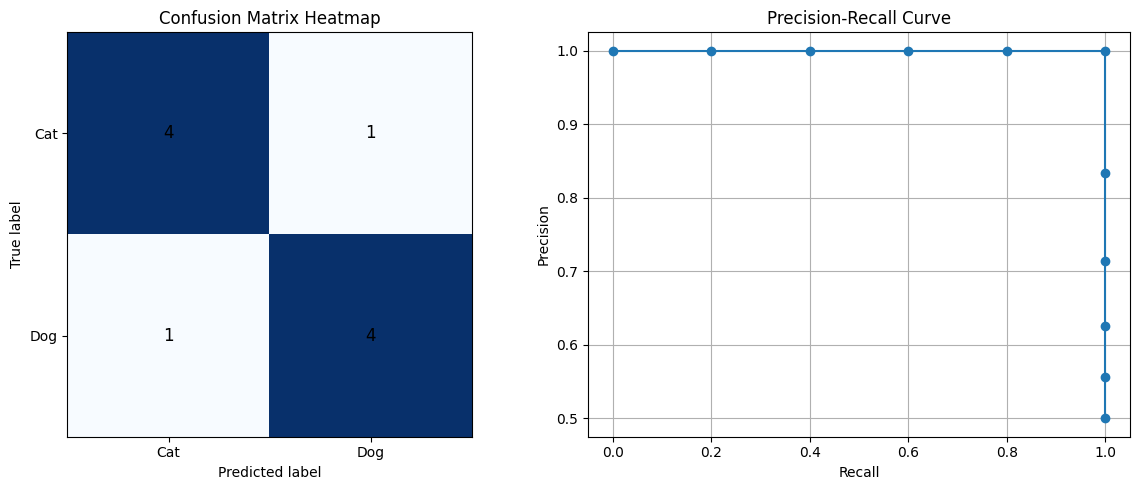

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Use the existing confusion matrix and add score values for a PR curve example.
y_scores = np.array([0.2, 0.3, 0.9, 0.85, 0.1, 0.4, 0.15, 0.95, 0.8, 0.05])
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks([0, 1], ['Cat', 'Dog'])
plt.yticks([0, 1], ['Cat', 'Dog'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=12)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, marker='o')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.tight_layout()
plt.show()

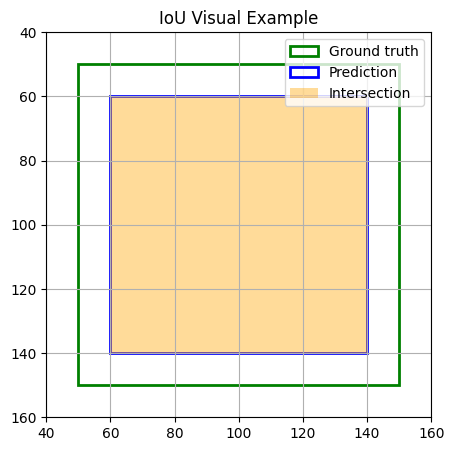

In [8]:
import matplotlib.patches as patches

plt.figure(figsize=(6, 5))
ax = plt.gca()
# Draw ground truth box
truth = patches.Rectangle((ground_truth[0], ground_truth[1]), ground_truth[2]-ground_truth[0], ground_truth[3]-ground_truth[1], linewidth=2, edgecolor='green', facecolor='none', label='Ground truth')
# Draw prediction box
pred = patches.Rectangle((prediction[0], prediction[1]), prediction[2]-prediction[0], prediction[3]-prediction[1], linewidth=2, edgecolor='blue', facecolor='none', label='Prediction')
# Draw intersection area
ix1, iy1 = max(ground_truth[0], prediction[0]), max(ground_truth[1], prediction[1])
ix2, iy2 = min(ground_truth[2], prediction[2]), min(ground_truth[3], prediction[3])
intersect = patches.Rectangle((ix1, iy1), max(0, ix2-ix1), max(0, iy2-iy1), linewidth=0, facecolor='orange', alpha=0.4, label='Intersection')
ax.add_patch(truth)
ax.add_patch(pred)
ax.add_patch(intersect)
ax.set_xlim(40, 160)
ax.set_ylim(40, 160)
ax.set_aspect('equal')
ax.set_title('IoU Visual Example')
ax.legend(loc='upper right')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

### What these graphs tell us

- The confusion matrix shows the exact counts of True Positives, False Positives, False Negatives, and True Negatives.
- The precision-recall curve shows how precision drops when recall increases, and why the F1-score is a balance.
- The IoU diagram shows that overlap is the only thing that matters for box quality, not box size alone.

## 6. Common questions and best practices

- **Why is accuracy not always enough?** Because it hides class imbalance. If 90% of images are cats, a model can be 90% accurate by always guessing cat.
- **When should I prefer precision?** When false positives are expensive or dangerous.
- **When should I prefer recall?** When missing a true object is worse than a false alarm.
- **When should I use IoU?** Every time your model predicts a bounding box in object detection.

### Quick checklist for choosing metrics:
- Binary classification with balanced classes: accuracy + F1.
- Binary classification with imbalanced classes: precision, recall, F1, and confusion matrix.
- Object detection: IoU, detection precision, recall, and mAP.

## 7. Summary

- Use numbers plus graphs together: metrics explain performance, graphs explain behavior.
- Confusion matrix and PR curve are especially helpful for seeing what mistakes a model makes.
- IoU is the simplest and most important metric for object detection box quality.